# File for plots

Read data generated in `reinforcement_learning.ipynb`. Plot and compare. Save plots.

### Imports and settings

#### Imports

In [1]:
# Imports

# General
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm # used for progress bar
import json
import os

# Specials
from pyworld3 import World3
from pyworld3.utils import plot_world_variables, standard_setup
from rewards import *
from control_maps_and_loops import *

#### Settings

In [2]:
# Settings
SAVE_PLOTS = True

In [3]:
TRAIN_ID = "2"
RL_ID = "50"
CTRLWORLD_ID = "DnI2"
CTRLWORLD_IDS = [CTRLWORLD_ID]
REWARD_NAME = "doughnut"

### Data extraction

#### Functions

In [4]:
def read_json(ctrlworld_id=None, reward_name=REWARD_NAME, train_id=TRAIN_ID, rl_id=RL_ID):
    # ctrlworld_id: choose None to read from standard world instead of control world

    noise_status = None
    seed = -1
    ctrl_names = []
    grid_size = None
    threshold = None
    lookahead = None

    if ctrlworld_id==None:
        json_path = f"datasets/ctrl_results/{reward_name}/train{train_id}_rl{rl_id}_addinf_std.json"
    else:
        json_path = f"datasets/ctrl_results/{reward_name}/train{train_id}_rl{rl_id}_addinf_ctrlwrld{ctrlworld_id}.json"
    json_file = os.path.join(os.getcwd(), json_path)

    with open(json_file) as fjson:
        table = json.load(fjson)[0]
    
    noise_status = table["noise"]

    if noise_status:
        if ctrlworld_id==None:
            seed = table["seed_gen_std"]
        else:
            seed = table["seed_gen_ctrl"]

    if ctrlworld_id!=None:
        threshold = table["threshold"]
        lookahead = table["lookahead"]
        num_ctrls = table["num_ctrl_funcs"]
        ctrl1 = table["ctrl1"]
        grid_sz1 = table["grid_size_1"]
        ctrl_names.append(ctrl1)
        grid_size = [grid_sz1]
        if num_ctrls > 1:
            ctrl2 = table["ctrl2"]
            grid_sz2 = table["grid_size_2"]
            ctrl_names.append(ctrl2)
            grid_size.append(grid_sz2)

    return noise_status, seed, ctrl_names, grid_size, threshold, lookahead


def read_saved_parquet(control_names=[], ctrlworld_id=None, reward_name=REWARD_NAME, train_id=TRAIN_ID, rl_id=RL_ID, expected_reward_cols=["J", "Jnorm", "nn", "nnnorm", "reward"], state_but_not_init_vars=["time"]):

    ctrl_vals = {}

    if ctrlworld_id!=None:
        parquet_path = f"datasets/ctrl_results/{reward_name}/train{train_id}_rl{rl_id}_control_world{ctrlworld_id}.parquet"
    else:
        parquet_path = f"datasets/ctrl_results/{reward_name}/train{train_id}_rl{rl_id}_standard_world.parquet"
    df = pd.read_parquet(parquet_path)

    col_names = df.columns # https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html
    state_var_names = [col for col in col_names if (col not in expected_reward_cols)]
    init_state_var_names = [var for var in state_var_names if (var not in state_but_not_init_vars)]

    init_state_var_vals = df[init_state_var_names].to_numpy()[0]
    Js = df["J"].to_numpy()
    Js_norm = df["Jnorm"].to_numpy()
    nn_approx = df["nn"].to_numpy()
    nn_approx_norm = df["nnnorm"].to_numpy()
    reward = df["reward"].to_numpy()

    if ctrlworld_id!=None:
        for control_name in control_names:
            current_ctrl_vals = df[f"{control_name}_control"].to_numpy()
            ctrl_vals[control_name] = current_ctrl_vals
    
    times = df["time"].to_numpy()
    start_year = int(times[0])
    end_year = int(times[-1])

    return state_var_names, init_state_var_vals, Js, Js_norm, nn_approx, nn_approx_norm, reward, ctrl_vals, start_year, end_year, times


def rebuild_world(start_year, end_year, noise_status, seed=-1, ctrl_names=[], ctrl_vals={}):
    # Returns: World3 object
    # NOTE: Currently we simply use standard setup for world (as this is what is done in reinforcement_learning.ipynb also) so changing the initial state variable values in the parquet file will not change the outcome of this function/World3 object

    world = World3(year_min=start_year, year_max=end_year, noise=noise_status, seed=seed)
    standard_setup(world)
    
    loop0(world)

    for k in range(1, world.n):
        for control_name in ctrl_names:
            value = ctrl_vals[control_name][k]
            set_control_to_constant(control_name, value, world)
        world._loopk_world3_fast(k-1, k, k-1, k)

    return world


def extract_data_from(ctrlworld_id=None, reward_name=REWARD_NAME, train_id=TRAIN_ID, rl_id=RL_ID):
    # Returns: World3 object along with J, Jnorm, nn, nnnorm, reward and dictionary with control values for each control variable, and times
    # NOTE: Currently we simply use standard setup for world (as this is what is done in reinforcement_learning.ipynb also) so changing the initial state variable values in the parquet file will not change the outcome of this function/World3 object

    # Step 1: Get data from JSON file
    noise_status, seed, ctrl_names, grid_size, threshold, lookahead = read_json(ctrlworld_id, reward_name, train_id, rl_id)

    # Step 2: Get data from parquet file
    state_var_names, init_state_var_vals, Js, Js_norm, nn_approx, nn_approx_norm, reward, ctrl_vals, start_year, end_year, times = read_saved_parquet(control_names=ctrl_names, ctrlworld_id=ctrlworld_id, reward_name=reward_name, train_id=train_id, rl_id=rl_id)

    # Step 3: Build world
    world = rebuild_world(start_year, end_year, noise_status, seed, ctrl_names, ctrl_vals)

    return world, Js, Js_norm, nn_approx, nn_approx_norm, reward, ctrl_vals, times


def extract_and_add_from(reward_dict_of_dicts, world3_objects, control_values, ctrlworld_id=None, reward_name=REWARD_NAME, train_id=TRAIN_ID, rl_id=RL_ID, local_id=None):
    # Returns World3 object and times, and stores information in existing dictionaries

    _, _, ctrl_names, _, _, _ = read_json(ctrlworld_id, reward_name, train_id, rl_id)

    world, Js, Js_norm, nn_approx, nn_approx_norm, reward, ctrl_vals, times = extract_data_from(ctrlworld_id, reward_name, train_id, rl_id)

    if local_id==None:
        id="std"
    else:
        id=local_id
    
    world3_objects[id] = world

    reward_dict_of_dicts["J"][id] = Js
    reward_dict_of_dicts["Jnorm"][id] = Js_norm
    reward_dict_of_dicts["nn"][id] = nn_approx
    reward_dict_of_dicts["nnnorm"][id] = nn_approx_norm
    reward_dict_of_dicts["reward"][id] = reward
    
    for control_name in ctrl_names:
        control_values[id][control_name] = ctrl_vals[control_name]

    return world, times


def setup_reward_dictionaries(reward_types=["J", "Jnorm", "nn", "nnnorm", "reward"]):
    reward_dict_of_dicts = {}
    for reward_type in reward_types:
        reward_dict_of_dicts[reward_type] = {}
    return reward_dict_of_dicts


def setup_all_dictionaries(ctrlworld_ids=[]):

    reward_dict_of_dicts = setup_reward_dictionaries()

    world3_objects = {} # idea: key std used for standard world, control world ID used as key for control worlds

    control_values = {} # idea: dictionary of dictionaries, control world IDs used as keys in main dictionary, "sub-dictionaries" have keys for each control variable name
    for ctrlworld_id in ctrlworld_ids:
        control_values[ctrlworld_id] = {}

    return reward_dict_of_dicts, world3_objects, control_values


def main_data_extraction():
    return

#### Run functions

In [5]:
train_ids=[]
all_ids = [None]

for n in range(1, 5+1):
     train_ids.append(str(n))
     all_ids.append(str(n))



reward_dict_of_dicts, worlds, control_values = setup_all_dictionaries(ctrlworld_ids=all_ids)
world_reference, time = extract_and_add_from(reward_dict_of_dicts, worlds, control_values, ctrlworld_id=None, train_id="1", rl_id="1", local_id="std")
for id in train_ids:
     _, _ = extract_and_add_from(reward_dict_of_dicts, worlds, control_values, ctrlworld_id=CTRLWORLD_ID, train_id=id, rl_id=id, local_id=id)

In [6]:
# Colormap/dictionary

colormap = {}
colormap["std"] = "blue" # (example)
colormap["1"] = "black" # (example)
# ...

### Plot no noise runs

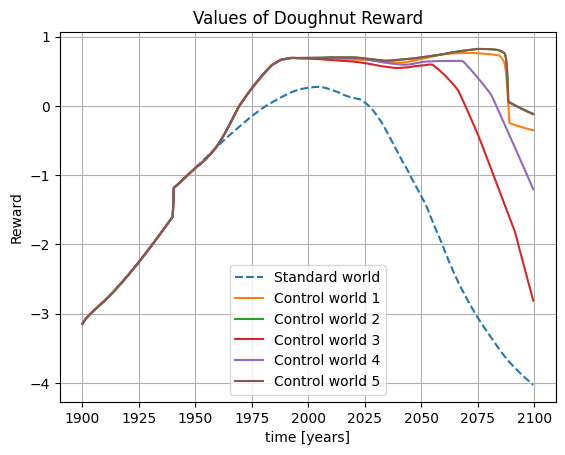

In [7]:
start = 0
end = -1
reward_type = "reward"

plt.plot(time[start:end], reward_dict_of_dicts[reward_type]["std"][start:end], label="Standard world", linestyle='--')
#plt.plot(time[start:end], reward_dict_of_dicts["nnnorm"]["std"][start:end], 'r', label="nn on standard, normalised", linestyle='--')

#plt.plot(time[start:end], reward_dict_of_dicts[reward_type]["1"][start:end], 'b', label="Controlled worlds")
for id in train_ids:
    plt.plot(time[start:end], reward_dict_of_dicts[reward_type][id][start:end], label=f"Control world {id}")
    #plt.plot(time[start:end], reward_dict_of_dicts["nnnorm"][ctrlworld_id][start:end], 'b', label="nn on control, normalised", linestyle='--')




plt.xlabel("time [years]")
plt.ylabel(f"Reward")
plt.title("Values of Doughnut Reward")
plt.legend()
plt.grid()
plt.show()



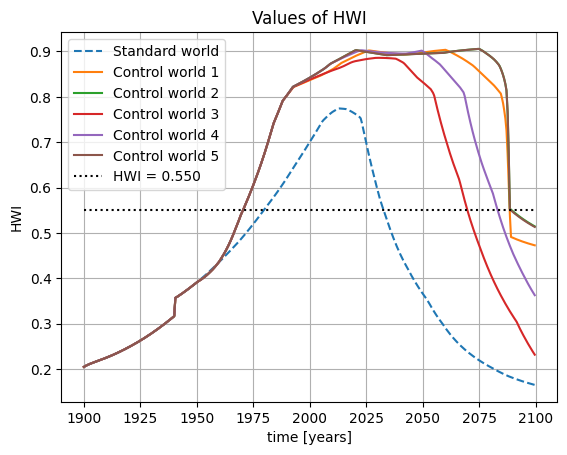

In [8]:
#plt.plot(time[start:end], 0.700*np.ones(len(time[start:end])), linestyle=':', color='black')

plt.plot(time[start:end], worlds["std"].hwi[start:end], label="Standard world", linestyle='--')

for id in train_ids:
    plt.plot(time[start:end], worlds[id].hwi[start:end], label=f"Control world {id}")

plt.plot(time[start:end], 0.550*np.ones(len(time[start:end])), linestyle=':', color='black', label='HWI = 0.550')


plt.xlabel("time [years]")
plt.ylabel("HWI")
plt.title("Values of HWI")
plt.legend()
plt.grid()
plt.show()

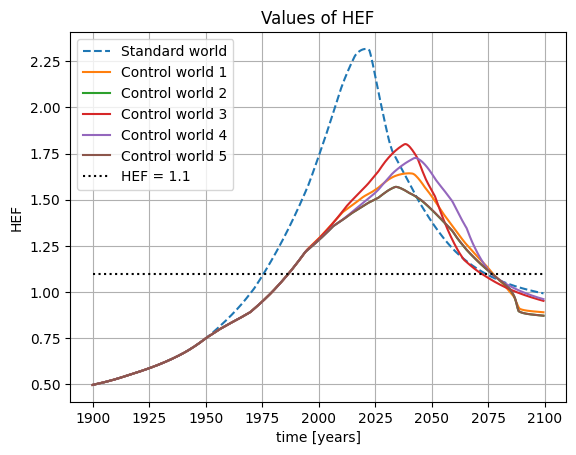

In [9]:
plt.plot(time[start:end], worlds["std"].ef[start:end], label="Standard world", linestyle='--')

for id in train_ids:
    plt.plot(time[start:end], worlds[id].ef[start:end], label=f"Control world {id}")

plt.plot(time[start:end], 1.1*np.ones(len(time[start:end])), linestyle=':', color='black', label='HEF = 1.1')

plt.xlabel("time [years]")
plt.ylabel("HEF")
plt.title("Values of HEF")
plt.legend()
plt.grid()
plt.show()

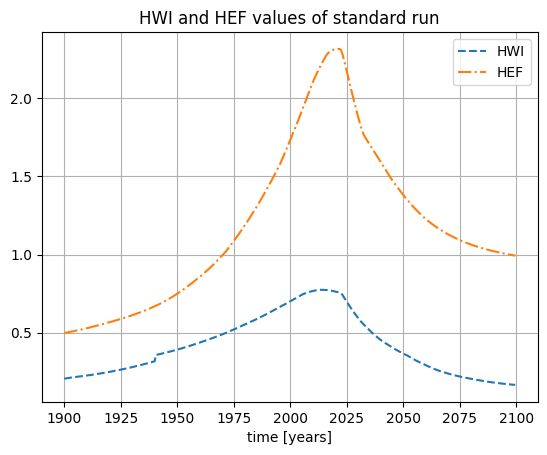

In [10]:
plt.plot(time[start:end], worlds["std"].hwi[start:end], linestyle='--', label='HWI')
plt.plot(time[start:end], worlds["std"].ef[start:end], linestyle='-.', label='HEF')
plt.legend()
plt.title('HWI and HEF values of standard run')
plt.xlabel('time [years]')
plt.grid()
plt.show()

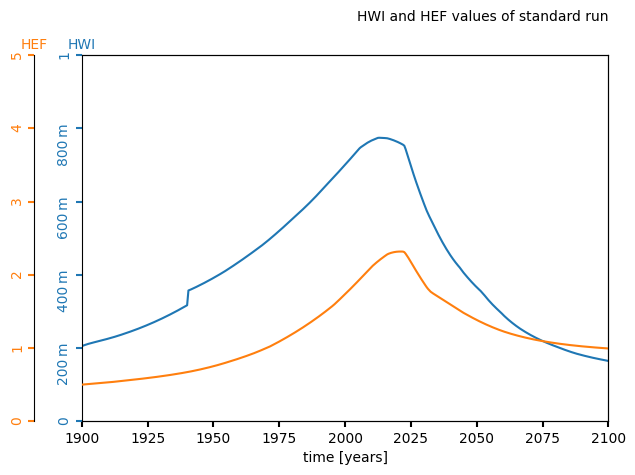

In [11]:
plot_world_variables(
    worlds["std"].time,
    [worlds["std"].hwi, worlds["std"].ef],
    ['HWI', 'HEF'],
    [[0.0, 1.0], [0.0, 5]],
    title='HWI and HEF values of standard run',
    grid=False
    )

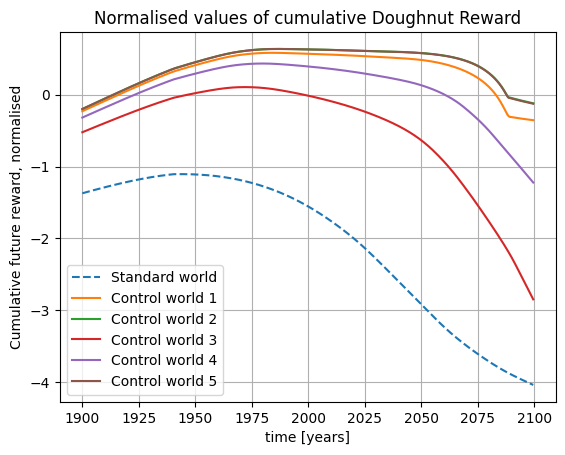

In [12]:
start = 0
end = -1
reward_type = "Jnorm"

plt.plot(time[start:end], reward_dict_of_dicts[reward_type]["std"][start:end], label="Standard world", linestyle='--')
#plt.plot(time[start:end], reward_dict_of_dicts["nnnorm"]["std"][start:end], 'r', label="nn on standard, normalised", linestyle='--')

#plt.plot(time[start:end], reward_dict_of_dicts[reward_type]["1"][start:end], 'b', label="Controlled worlds")
for id in train_ids:
    plt.plot(time[start:end], reward_dict_of_dicts[reward_type][id][start:end], label=f"Control world {id}")
    #plt.plot(time[start:end], reward_dict_of_dicts["nnnorm"][ctrlworld_id][start:end], 'b', label="nn on control, normalised", linestyle='--')




plt.xlabel("time [years]")
plt.ylabel(f"Cumulative future reward, normalised")
plt.title("Normalised values of cumulative Doughnut Reward")
plt.legend()
plt.grid()
plt.show()



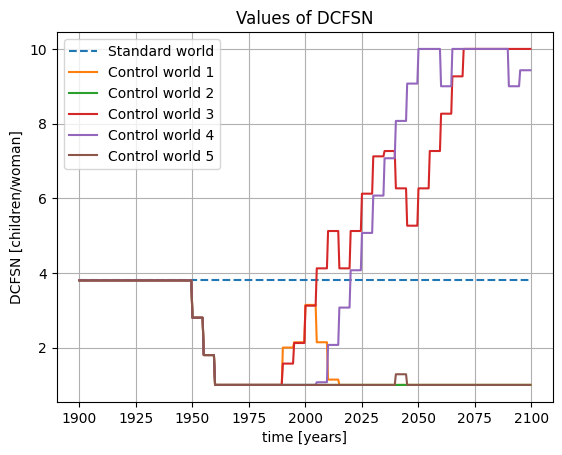

In [13]:
control_name = "DCFSN"

start_1950 = 100

plt.plot(time[start:end], 3.8*np.ones(len(time[start:end])), label="Standard world", linestyle='--')

for id in train_ids:
    plt.plot(time[start:end], worlds[id].dcfsn[start:end], label=f"Control world {id}", linestyle='-')
    # control_values[id][control_name][start:end]

plt.ylabel("DCFSN [children/woman]"), 
plt.xlabel("time [years]") 
#plt.title("DCFSN")
plt.grid()
plt.title("Values of DCFSN")
plt.legend()
plt.show()

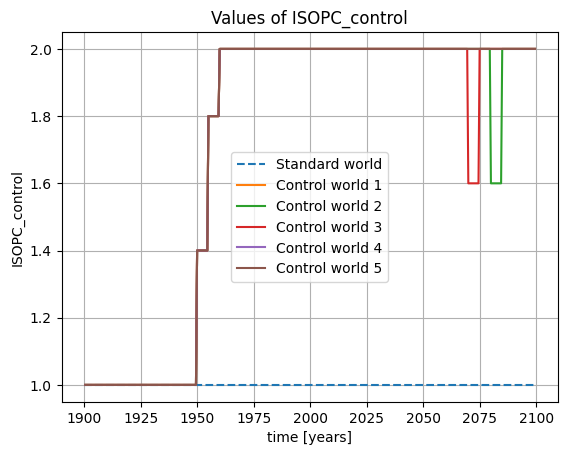

In [14]:
control_name = "ISOPC"


#plt.plot(time[start_1950:end], worlds["1"].isopc[start_1950:end], label=f"Control world {1}", linestyle='--')
#plt.plot(time[start_1950:end], control_values["1"][control_name][start_1950:end], label=f"Control world {1}", linestyle='--')

#print(worlds["std"].isopc[start_1950:end])
#print(worlds["1"].isopc[start_1950:end])
#print(control_values["1"]["ISOPC"][start_1950:end])

plt.plot(time[start:end], 1.0*np.ones(len(time[start:end])), label="Standard world", linestyle='--')

for id in train_ids:
    #plt.plot(time[start:end], worlds[id].isopc[start:end], label=f"Control world {id}", linestyle='-')
    #plt.plot(time[start:end], worlds[id].isopc[start:end], label=f"Control world {id}", linestyle='--')
    plt.plot(time[start:end], control_values[id][control_name][start:end], label=f"Control world {id}", linestyle='-')
    # control_values[id][control_name][start:end]

plt.ylabel("ISOPC_control"), 
plt.xlabel("time [years]") 
plt.grid()
plt.title("Values of ISOPC_control")
plt.legend()
plt.show()

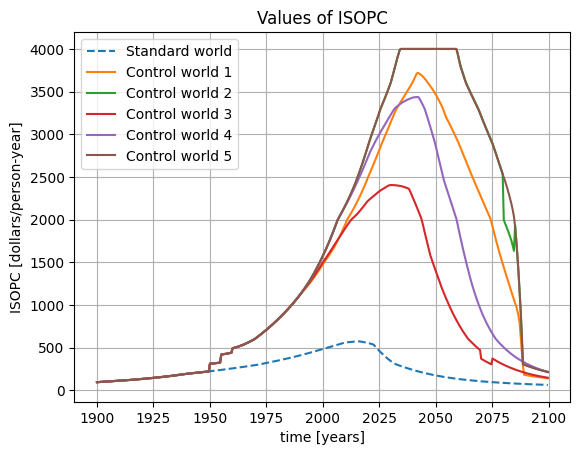

In [15]:
control_name = "ISOPC"


#plt.plot(time[start_1950:end], worlds["1"].isopc[start_1950:end], label=f"Control world {1}", linestyle='--')
#plt.plot(time[start_1950:end], control_values["1"][control_name][start_1950:end], label=f"Control world {1}", linestyle='--')

#print(worlds["std"].isopc[start_1950:end])
#print(worlds["1"].isopc[start_1950:end])
#print(control_values["1"]["ISOPC"][start_1950:end])

plt.plot(time[start:end], worlds["std"].isopc[start:end], label="Standard world", linestyle='--')

for id in train_ids:
    plt.plot(time[start:end], worlds[id].isopc[start:end], label=f"Control world {id}", linestyle='-')
    #plt.plot(time[start:end], worlds[id].isopc[start:end], label=f"Control world {id}", linestyle='--')
    # control_values[id][control_name][start:end]

plt.ylabel("ISOPC [dollars/person-year]"), 
plt.xlabel("time [years]") 
plt.grid()
plt.title("Values of ISOPC")
plt.legend()
plt.show()

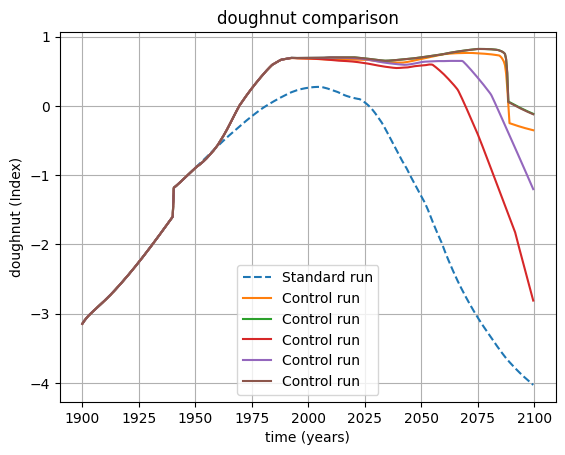

In [16]:
plt.plot(time[start:end], reward_dict_of_dicts["reward"]["std"][start:end], label="Standard run", linestyle='--')


for id in train_ids:
    plt.plot(time[start:end], reward_dict_of_dicts["reward"][id][start:end], label="Control run")


plt.xlabel("time (years)")
plt.legend()
plt.ylabel(f"{REWARD_NAME} (Index)")
plt.title(f"{REWARD_NAME} comparison")
plt.grid()
plt.savefig(f"plots_clean/{REWARD_NAME}/comparison_{CTRLWORLD_ID}")
plt.show()





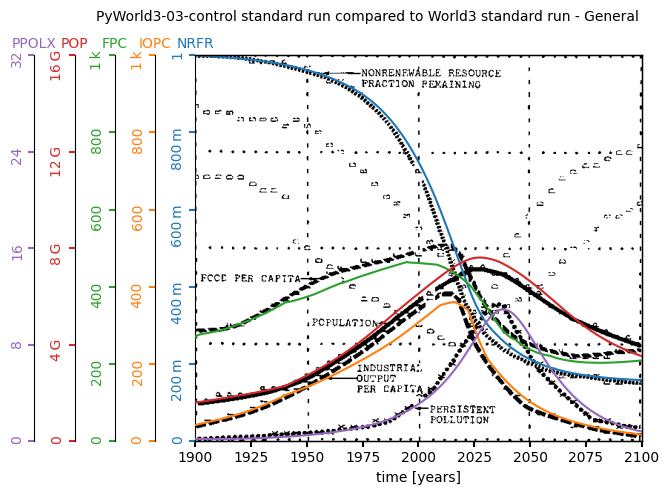

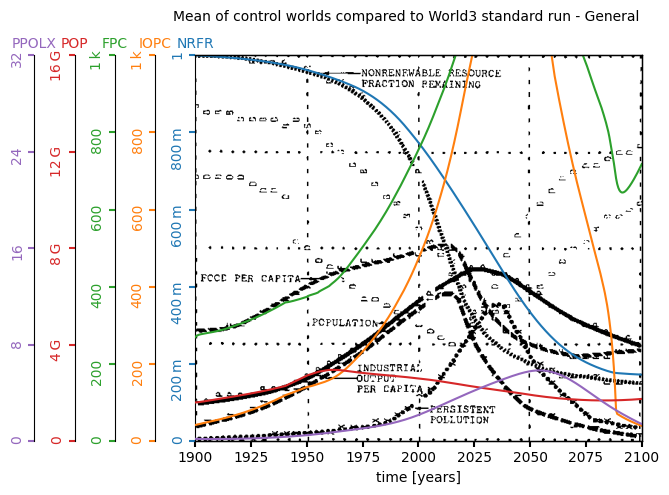

In [17]:
# train_ids

reward_name = REWARD_NAME

n = len(train_ids)
sum_nrfr=np.zeros(len(time[start:end])+1)
sum_iopc=np.zeros(len(time[start:end])+1)
sum_fpc=np.zeros(len(time[start:end])+1)
sum_pop=np.zeros(len(time[start:end])+1)
sum_ppolx=np.zeros(len(time[start:end])+1)

for id in train_ids:
    sum_nrfr += worlds[id].nrfr
    sum_iopc += worlds[id].iopc
    sum_fpc += worlds[id].fpc
    sum_pop += worlds[id].pop
    sum_ppolx += worlds[id].ppolx

mean_nrfr = sum_nrfr/n
mean_iopc = sum_iopc/n
mean_fpc = sum_fpc/n
mean_pop = sum_pop/n
mean_ppolx = sum_ppolx/n


plot_world_variables(
    worlds["std"].time,
    [worlds["std"].nrfr, worlds["std"].iopc, worlds["std"].fpc, worlds["std"].pop, worlds["std"].ppolx],
    ["NRFR", "IOPC", "FPC", "POP", "PPOLX"],
    [[0, 1], [0, 1e3], [0, 1e3], [0, 16e9], [0, 32]],
    img_background="./img/fig7-7.png",
    figsize=(7, 5),
    title="PyWorld3-03-control standard run compared to World3 standard run - General",
)
plt.show()

#plt.plot(worlds["std"].time[start:end], worlds["std"].nrfr[start:end], linestyle='--')
     
plot_world_variables(
    worlds["1"].time,
    [mean_nrfr, mean_iopc, mean_fpc, mean_pop, mean_ppolx],
    ["NRFR", "IOPC", "FPC", "POP", "PPOLX"],
    [[0, 1], [0, 1e3], [0, 1e3], [0, 16e9], [0, 32]],
    img_background="./img/fig7-7.png",
    figsize=(7, 5),
    title="Mean of control worlds compared to World3 standard run - General",
)

plt.show()     





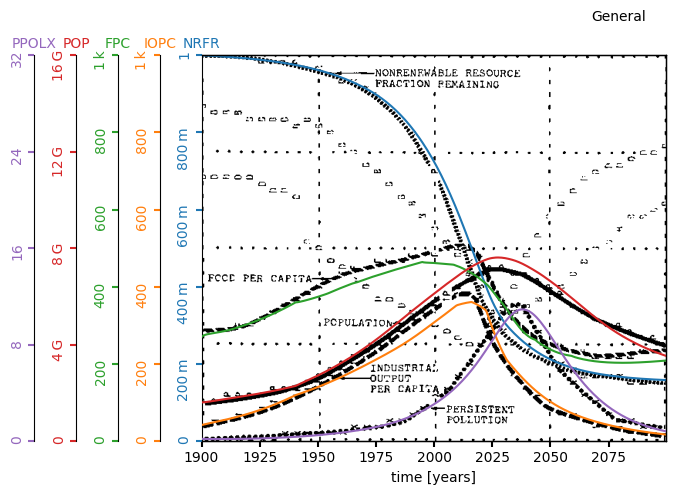

In [18]:
world_reference = worlds["std"]

plot_world_variables(
    world_reference.time[start:end],
    [world_reference.nrfr[start:end], world_reference.iopc[start:end], world_reference.fpc[start:end], world_reference.pop[start:end], world_reference.ppolx[start:end]],
    ["NRFR", "IOPC", "FPC", "POP", "PPOLX"],
    [[0, 1], [0, 1e3], [0, 1e3], [0, 16e9], [0, 32]],
    img_background="./img/fig7-7.png",
    figsize=(7, 5),
    title="General",
)
plt.show() 

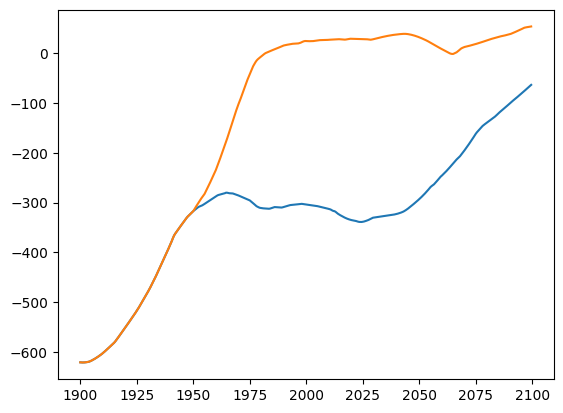

In [19]:
reward_type = "nn"

plt.plot(time[start:end], reward_dict_of_dicts[reward_type]["std"][start:end])
plt.plot(time[start:end], reward_dict_of_dicts[reward_type]["1"][start:end])
plt.show()

In [20]:
print(np.max(worlds["std"].isopc))
for id in train_ids:
    print(id, np.max(worlds[id].isopc))

print(worlds["5"].isopc[150:200]-worlds["3"].isopc[150:200])

572.7013551451116
1 3718.911248123609
2 4000.0
3 2404.5378431623612
4 3436.4722036832627
5 4000.0
[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          2.01006278  4.0645986   6.15970406  8.29699493 10.47955989
 12.71073073 14.9937418  17.33166195 20.86621291 23.54223186 28.31339691
 33.18250731 38.15373972 43.23979551 48.44496263 53.77246445 59.23743874
 64.8456382  70.60332193]


### Plots for noise analysis

In [21]:
# TN stands for Train No (noise) and TY stands for Train Yes (noise)
# So TN ids were trained without noise and TY ids were trained with noise
all_noise_world_ids=["TN-NoNoise1", "TN-Noise11", "TN-Noise12", "TN-Noise13", "TN-Noise14", "TN-Noise15", "TY-NoNoise1", "TY-Noise11", "TY-Noise12", "TY-Noise13", "TY-Noise14", "TY-Noise15"]
all_noise_rewards, all_noise_worlds, all_noise_controls = setup_all_dictionaries(all_noise_world_ids)

TN_ID = "11"
TY_ID = "12"

_, _ = extract_and_add_from(all_noise_rewards, all_noise_worlds, all_noise_controls, ctrlworld_id="NoNoise1", train_id=TN_ID, rl_id=TN_ID, local_id="TN-NoNoise1")
_, _ = extract_and_add_from(all_noise_rewards, all_noise_worlds, all_noise_controls, ctrlworld_id="NoNoise1", train_id=TY_ID, rl_id=TY_ID, local_id="TY-NoNoise1")

for n in range(11, 15+1):
    _, _ = extract_and_add_from(all_noise_rewards, all_noise_worlds, all_noise_controls, ctrlworld_id=f"Noise{n}", train_id=TN_ID, rl_id=TN_ID, local_id=f"TN-Noise{n}")
    _, _ = extract_and_add_from(all_noise_rewards, all_noise_worlds, all_noise_controls, ctrlworld_id=f"Noise{n}", train_id=TY_ID, rl_id=TY_ID, local_id=f"TY-Noise{n}")

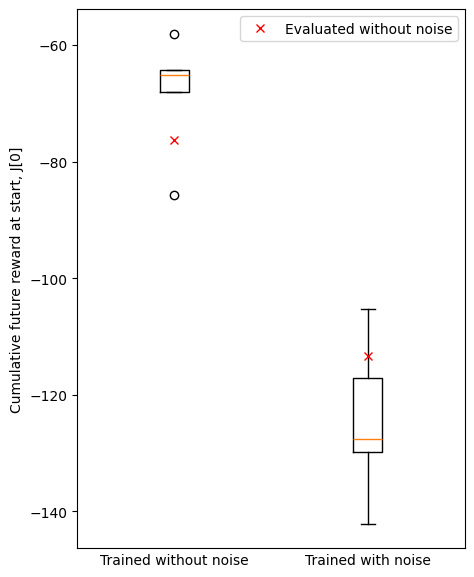

In [22]:
#print(all_noise_worlds["TN-Noise11"].time[start:end])

reward_type = "J"
#print(all_noise_rewards[reward_type]["TN_Noise11"])
#print(all_noise_rewards[reward_type])

TN_EvalN_J0 = all_noise_rewards["J"]["TN-NoNoise1"][0]
TY_EvalN_J0 = all_noise_rewards["J"]["TY-NoNoise1"][0]

TN_EvalY_J0s = []
TY_EvalY_J0s = []
for n in range(11, 15+1):
    TN_EvalY_J0s.append(all_noise_rewards["J"][f"TN-Noise{n}"][0])
    TY_EvalY_J0s.append(all_noise_rewards["J"][f"TY-Noise{n}"][0])
TN_EvalY_J0s = np.array(TN_EvalY_J0s)
TY_EvalY_J0s = np.array(TY_EvalY_J0s)

# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html
# https://matplotlib.org/stable/gallery/statistics/boxplot_demo.html
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.boxplot.html
# https://scipy-lectures.org/intro/matplotlib/auto_examples/pretty_plots/plot_boxplot_ext.html

"""
#plt.boxplot(TN_EvalY_J0s)
plt.boxplot(TY_EvalY_J0s)
plt.plot(TY_EvalN_J0)
plt.xticks([])
plt.show()
"""

"""
fig, ax = plt.subplots(figsize=(4, 4))
ax.boxplot(TN_EvalY_J0s)
ax.plot([1], TN_EvalN_J0, marker='x', color='red', linestyle='none', label='Evaluated without noise')
ax.set_xticks([1])
ax.set_xticklabels(["Trained without noise"])
ax.tick_params(axis='x', length=0)
ax.set_ylabel('Cumulative future reward at start, J[0]')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(TY_EvalY_J0s)
ax.plot([1], TY_EvalN_J0, marker='x', color='red', linestyle='none', label='Evaluated without noise')
ax.set_xticks([1])
ax.set_xticklabels(["Trained with noise"])
ax.tick_params(axis='x', length=0)
ax.set_ylabel('Cumulative future reward at start, J[0]')
ax.legend()
plt.show()
"""

fig, ax = plt.subplots(figsize=(5, 7))
ax.boxplot([TN_EvalY_J0s, TY_EvalY_J0s])
ax.plot([1, 2], [TN_EvalN_J0, TY_EvalN_J0], marker='x', color='red', linestyle='none', label='Evaluated without noise')
ax.set_xticks([1, 2])
ax.set_xticklabels(["Trained without noise", "Trained with noise"])
ax.tick_params(axis='x', length=0)
ax.set_ylabel('Cumulative future reward at start, J[0]')
ax.legend()
plt.show()

# reward_dict_of_dicts[reward_type][id][start:end]
#plt.plot(all_noise_worlds["TN-Noise11"].time[start:end], all_noise_rewards[reward_type]["TN-Noise11"][start:end])
#plt.show()

In [25]:
print(np.median(TN_EvalY_J0s))
print(np.min(TN_EvalY_J0s))
print(np.max(TN_EvalY_J0s))
print(TN_EvalN_J0)

-65.10052498977863
-85.65172701892135
-58.03584144452402
-76.28716727560605


In [26]:
print(np.median(TY_EvalY_J0s))
print(np.min(TY_EvalY_J0s))
print(np.max(TY_EvalY_J0s))
print(TY_EvalN_J0)

-127.64679156508886
-142.0937709783036
-105.2034944204415
-113.39953232456176
